<a href="https://colab.research.google.com/github/kbmathewsphd/My_First_ML_Proj/blob/main/Weekly_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

[ 7.41622651 30.56553439  0.67784755 ... 27.31658799 20.69370116
 10.8797342 ] [20.98656628  9.38367884 21.75234793 ... 15.80315333 11.188022
 13.16141845]
LR MSE (Train): 36.74023064886091
LR r2 (Train): 0.8172098918914885
LR MSE (Test): 37.600152054314044
LR r2 (Test): 0.8147488687310956


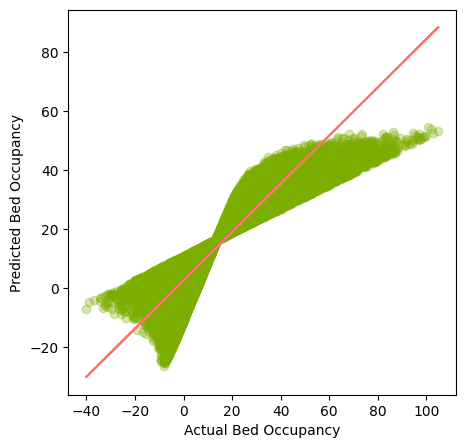

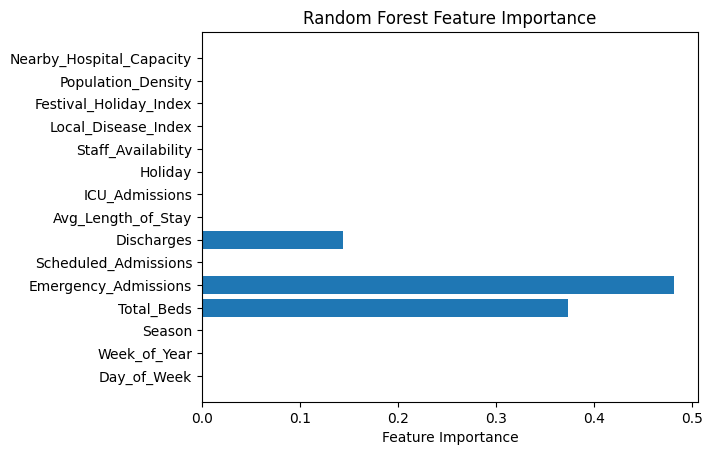

In [ ]:
# **Bed Occ Project**

# **Load Data**

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor


df=pd.read_csv ('https://raw.githubusercontent.com/kbmathewsphd/bed_occ_mod1/refs/heads/main/bed_occupancy_dataset.csv')


## **Data Seperation as X and Y**

y=df ['Bed_Occupancy_Rate']


x=df.drop('Bed_Occupancy_Rate', axis=1)


## **Data Splitting**

from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=100)


# **Model Building**

## **Linear Regression**

### **Training the Model**

from sklearn.linear_model import LinearRegression

lr=LinearRegression()
lr.fit(x_train, y_train)

### **Applying the Model to make a prediction**

y_lr_train_pred=lr.predict(x_train)
y_lr_test_pred=lr.predict(x_test)

print (y_lr_train_pred, y_lr_test_pred)

# y_lr_test_pred

### **Evaluate Model Performance**

# y_lr_train_pred

from sklearn.metrics import mean_squared_error, r2_score

lr_train_mse=mean_squared_error(y_train, y_lr_train_pred)
lr_train_r2=r2_score(y_train, y_lr_train_pred)

lr_test_mse = mean_squared_error(y_test, y_lr_test_pred)
lr_test_r2 = r2_score(y_test, y_lr_test_pred)

print('LR MSE (Train):', lr_train_mse)
print('LR r2 (Train):' , lr_train_r2)
print('LR MSE (Test):' , lr_test_mse)
print('LR r2 (Test):' , lr_test_r2)

lr_results = pd.DataFrame(['Linear regression', lr_train_mse, lr_train_r2, lr_test_mse, lr_test_r2]).transpose()
lr_results.columns = ['Method', 'Training MSE', 'Training R2', 'Test MSE', 'Test R2']

# lr_results

## **Random Forest**

### **Training the Model**



rf=RandomForestRegressor(max_depth=2, random_state=100)
rf.fit(x_train, y_train)

### **Applying the Model to make a Prediction**

y_rf_train_pred=rf.predict(x_train)
y_rf_test_pred=rf.predict(x_test)

### **Evaluate Model Performance**



rf_train_mse=mean_squared_error(y_train, y_rf_train_pred)
rf_train_r2=r2_score(y_train, y_rf_train_pred)

rf_test_mse = mean_squared_error(y_test, y_rf_test_pred)
rf_test_r2 = r2_score(y_test, y_rf_test_pred)

rf_results = pd.DataFrame(['Random Forest', rf_train_mse, rf_train_r2, rf_test_mse, rf_test_r2]).transpose()
rf_results.columns = ['Method', 'Training MSE', 'Training R2', 'Test MSE', 'Test R2']

rf_results

## **Model Comparison**


df_models = pd.concat([lr_results, rf_results], axis=0)

df_models
# df_models.reset_index(drop=True)
df_models = df_models.reset_index(drop=True)

## **Data Visualisation of Prediction Results**



plt.figure(figsize=(5,5))
plt.scatter(x=y_train, y=y_lr_train_pred, c="#7CAE00", alpha=0.3)

z=np.polyfit(y_train, y_lr_train_pred, 1)
p=np.poly1d(z)

plt.plot(y_train, p(y_train), '#F8766D')

plt.xlabel('Actual Bed Occupancy')
plt.ylabel('Predicted Bed Occupancy')
plt.show()

# which hospital factors affect bed occupancy the most

importance = rf.feature_importances_
features = x.columns

plt.barh(features, importance)
plt.xlabel("Feature Importance")
plt.title("Random Forest Feature Importance")
plt.show()
